In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 16
Total threads: 128,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34935,Workers: 16
Dashboard: http://127.0.0.1:8787/status,Total threads: 128
Started: Just now,Total memory: 0.98 TiB
Comm: tcp://127.0.0.1:33105,Total threads: 8
Dashboard: http://127.0.0.1:39429/status,Memory: 62.93 GiB
Nanny: tcp://127.0.0.1:38943,


In [2]:
foldername = '/home/edavenport/analysis/TPOSE6_VelocityAssim/sep2012/fit_to_obs/compare_with_without_vel/'
iter = 14
data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_withhold/run_iter14/'

### Load MITgcm

In [3]:
## Read in ITER 0 Diagnostics 
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import xarray as xr
from xmitgcm import open_mdsdataset
import numpy as np
import xarray as xr

grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

num_diags = 122 #
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags+1,itPerFile)

prefix = ['diag_state','diag_surf']
ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)
ds['XC'] = ds.XC.astype(float)
ds['YC'] = ds.YC.astype(float)
ds['Z'] = ds.Z.astype(float)
ds['XG'] = ds.XG.astype(float)
ds['YG'] = ds.YG.astype(float)

In [4]:
iter = 22
data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
ds_vel = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)
ds_vel['XC'] = ds_vel.XC.astype(float)
ds_vel['YC'] = ds_vel.YC.astype(float)
ds_vel['Z'] = ds_vel.Z.astype(float)
ds_vel['XG'] = ds_vel.XG.astype(float)
ds_vel['YG'] = ds_vel.YG.astype(float)

### Load SST Data (oisst)

In [5]:
OISST_filename = '/data/SO6/TPOSE/constraints/sst/mw_fusion_tpose6_2012'

# Read the binary file (big-endian float32)
with open(OISST_filename, 'rb') as f:
    OISST = np.fromfile(f, dtype='>f4')

# Define dimensions
nx, ny, nt = len(ds.XC), len(ds.YC), 366

# Reshape (Fortran order to match MATLAB)
OISST = OISST.reshape((nx, ny, nt), order='F')
OISST = OISST.transpose(1,0,2)

# Convert to xarray DataArray
OISST_da = xr.DataArray(
    OISST[:,:,-len(ds.time):],  # Align time dimension
    dims=['YC', 'XC', 'time'],
    coords={'YC': ds.YC, 'XC': ds.XC, 'time': ds.time},
    name='OISST'
)

In [6]:
# SST weights
uncertainty_file = '/data/SO6/TPOSE/model_setup/linked_files/TP6/SST_error_tpose6_17Sto17N.bin'

# Read the binary file (big-endian float32)
with open(uncertainty_file, 'rb') as f:
    weights = np.fromfile(f, dtype='>f4')

# Define dimensions
nx, ny = len(ds.XC), len(ds.YC)

# Reshape (Fortran order to match MATLAB)
weights = weights.reshape((nx, ny), order='F')
weights = weights.transpose(1,0)

# Convert to xarray DataArray
weights_da = xr.DataArray(
    weights,  # Align time dimension
    dims=['YC', 'XC'],
    coords={'YC': ds.YC, 'XC': ds.XC},
    name='weights'
)

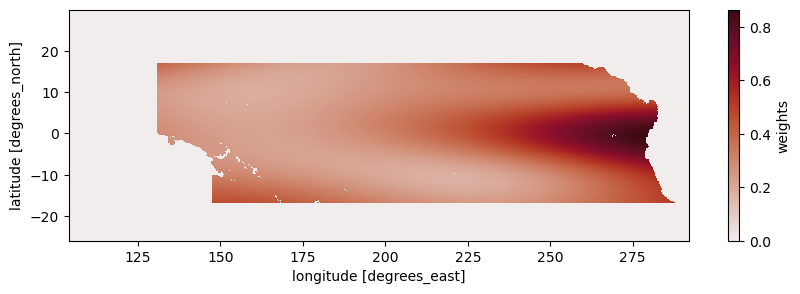

In [7]:
fig,ax = plt.subplots(figsize=(10,3))
weights_da.plot(cmap=cmo.amp)

### SST - MITgcm difference

In [8]:
rms_sst = np.sqrt(((ds.THETA.isel(Z=0).compute() - OISST_da)**2).mean(dim='time')).compute()
rms_sst_1 = np.sqrt(((ds.THETA.isel(Z=0).isel(time=slice(0,62)).compute() - OISST_da.isel(time=slice(0,62)))**2).mean(dim='time')).compute()
rms_sst_2 = np.sqrt(((ds.THETA.isel(Z=0).isel(time=slice(62,None)).compute() - OISST_da.isel(time=slice(62,None)))**2).mean(dim='time')).compute()

rms_sst_vel = np.sqrt(((ds_vel.THETA.isel(Z=0).compute() - OISST_da)**2).mean(dim='time')).compute()
rms_sst_vel_1 = np.sqrt(((ds_vel.THETA.isel(Z=0).isel(time=slice(0,62)).compute() - OISST_da.isel(time=slice(0,62)))**2).mean(dim='time')).compute()
rms_sst_vel_2 = np.sqrt(((ds_vel.THETA.isel(Z=0).isel(time=slice(62,None)).compute() - OISST_da.isel(time=slice(62,None)))**2).mean(dim='time')).compute()

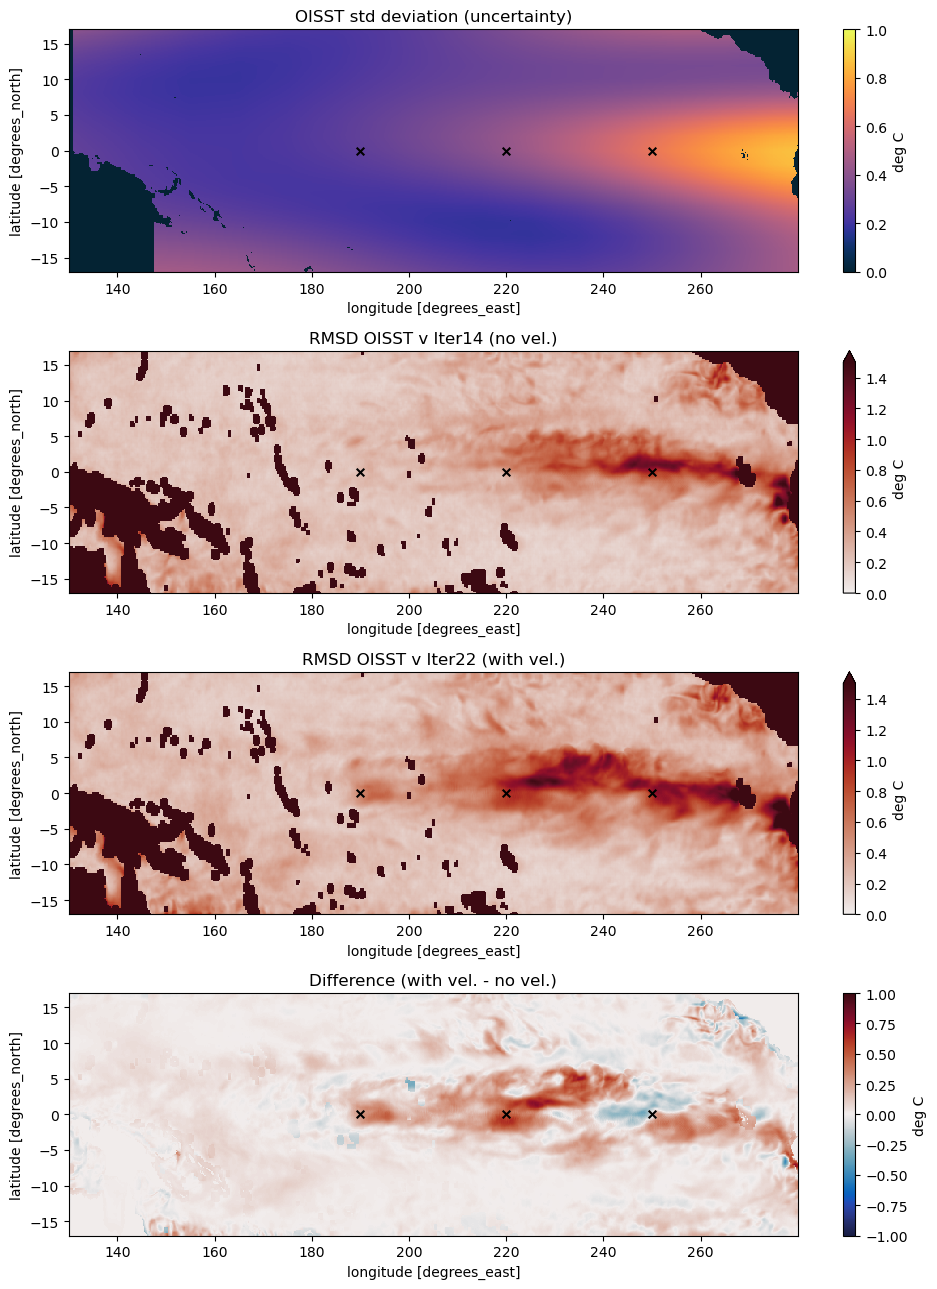

In [12]:
TAO_lon = np.array([190.0, 220.0, 250.0])
TAO_lat = np.array([0.0, 0.0, 0.0])

fig, ax = plt.subplots(figsize=(10,13),nrows=4)

weights_da.sel(YC=slice(-17,17),XC=slice(130,280)).plot(ax=ax[0],vmin=0.0,vmax=1.0,cmap=cmo.thermal,cbar_kwargs={'label':'deg C'})
ax[0].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[0].set_title('OISST std deviation (uncertainty)')

rms_sst.sel(YC=slice(-17,17),XC=slice(130,280)).plot(ax=ax[1],vmin=0,vmax=1.5,cmap=cmo.amp,cbar_kwargs={'label':'deg C'})
ax[1].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[1].set_title('RMSD OISST v Iter14 (no vel.)')

rms_sst_vel.sel(YC=slice(-17,17),XC=slice(130,280)).plot(ax=ax[2],vmin=0,vmax=1.5,cmap=cmo.amp,cbar_kwargs={'label':'deg C'})
ax[2].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[2].set_title('RMSD OISST v Iter22 (with vel.)')

(rms_sst_vel.sel(YC=slice(-17,17),XC=slice(130,280)) - rms_sst.sel(YC=slice(-17,17),XC=slice(130,280))).plot(ax=ax[3],vmin=-1,vmax=1,cmap=cmo.balance,cbar_kwargs={'label':'deg C'})
ax[3].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[3].set_title('Difference (with vel. - no vel.)')


plt.tight_layout()
fig.savefig(foldername + 'RMSD_OISST_vel_withhold.png')

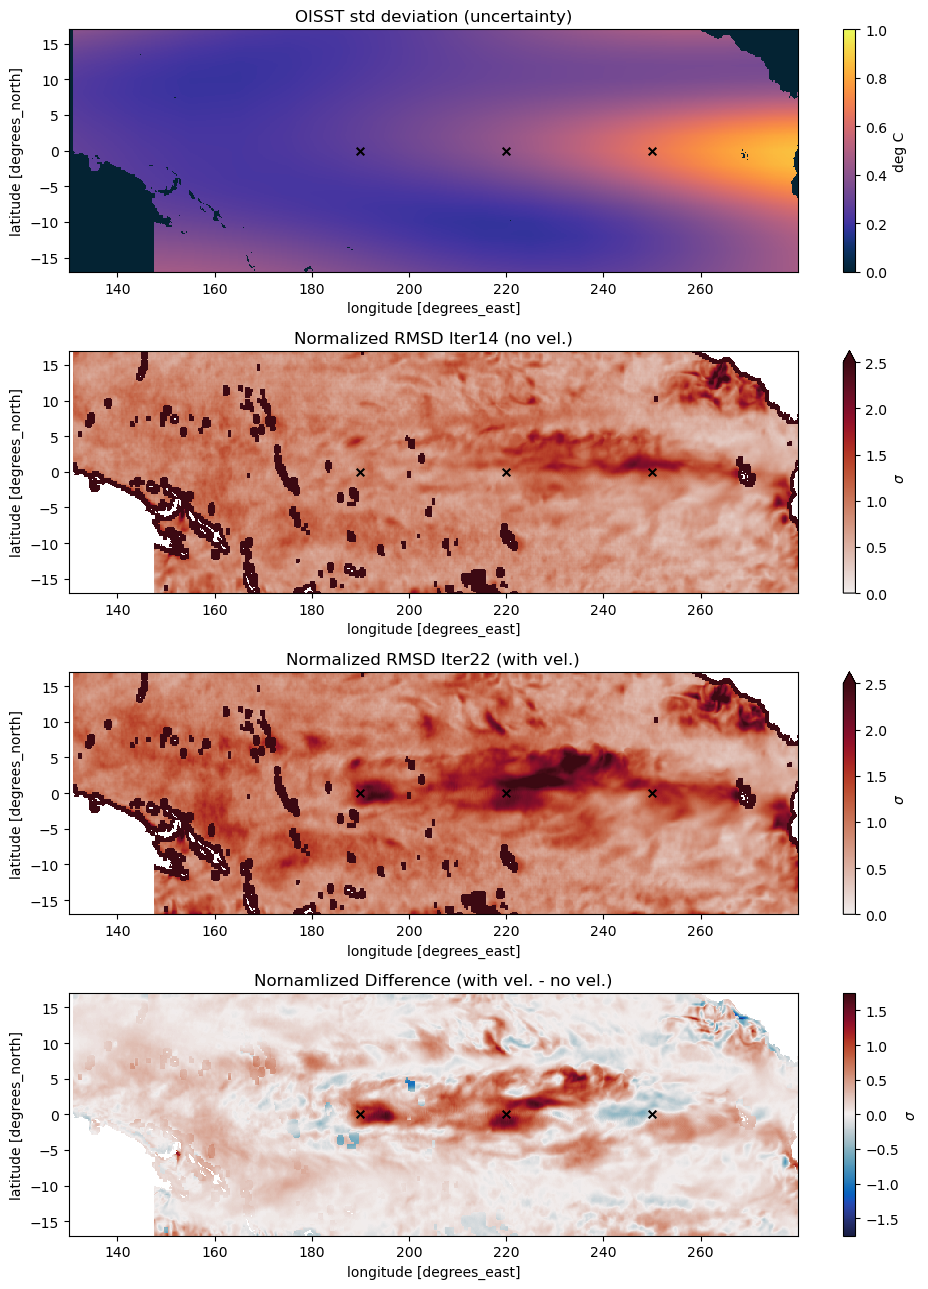

In [20]:
fig, ax = plt.subplots(figsize=(10,13),nrows=4)

weights_da.sel(YC=slice(-17,17),XC=slice(130,280)).plot(ax=ax[0],vmin=0.0,vmax=1.0,cmap=cmo.thermal,cbar_kwargs={'label':'deg C'})
ax[0].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[0].set_title('OISST std deviation (uncertainty)')

(rms_sst/weights_da).sel(YC=slice(-17,17),XC=slice(130,280)).plot(ax=ax[1],vmin=0,vmax=2.5,cmap=cmo.amp,cbar_kwargs={'label':r'$\sigma$'})
ax[1].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[1].set_title('Normalized RMSD Iter14 (no vel.)')

(rms_sst_vel/weights_da).sel(YC=slice(-17,17),XC=slice(130,280)).plot(ax=ax[2],vmin=0,vmax=2.5,cmap=cmo.amp,cbar_kwargs={'label':r'$\sigma$'})
ax[2].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[2].set_title('Normalized RMSD Iter22 (with vel.)')

diff = (rms_sst_vel - rms_sst)/weights_da
diff.sel(YC=slice(-17,17),XC=slice(130,280)).plot(ax=ax[3],vmin=-1.75,vmax=1.75,cmap=cmo.balance,cbar_kwargs={'label':r'$\sigma$'})
ax[3].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[3].set_title('Nornamlized Difference (with vel. - no vel.)')


plt.tight_layout()
fig.savefig(foldername + 'RMSD_OISST_vel_withhold_normalized.png')

### Load SSH Data (rads)

In [ ]:
#rads_ja_tpose6_QC and rads_c2_tpose6_QC
rads_ja_filename = '/data/SO6/TPOSE/constraints/rads/rads_ja_tpose6_QC_2012'
rads_c2_filename = '/data/SO6/TPOSE/constraints/rads/rads_c2_tpose6_QC_2012'

# Read the binary file (big-endian float32)
with open(rads_ja_filename, 'rb') as f:
    rads_ja = np.fromfile(f, dtype='>f4')

# Define dimensions
nx, ny, nt = len(ds.XC), len(ds.YC), 366

# Reshape (Fortran order to match MATLAB)
rads_ja = rads_ja.reshape((nx, ny, nt), order='F')
rads_ja = rads_ja.transpose(1,0,2)

# Convert to xarray DataArray
rads_ja_da = xr.DataArray(
    rads_ja[:,:,-len(ds.time):]/100,  # Align time dimension
    dims=['YC', 'XC', 'time'],
    coords={'YC': ds.YC, 'XC': ds.XC, 'time': ds.time},
    name='rads_ja'
)

# Read the binary file (big-endian float32)
with open(rads_c2_filename, 'rb') as f:
    rads_c2 = np.fromfile(f, dtype='>f4')

# Define dimensions
nx, ny, nt = len(ds.XC), len(ds.YC), 366

# Reshape (Fortran order to match MATLAB)
rads_c2 = rads_c2.reshape((nx, ny, nt), order='F')
rads_c2 = rads_c2.transpose(1,0,2)

# Convert to xarray DataArray
rads_c2_da = xr.DataArray(
    rads_c2[:,:,-len(ds.time):]/100,  # Align time dimension, convert from cm to m
    dims=['YC', 'XC', 'time'],
    coords={'YC': ds.YC, 'XC': ds.XC, 'time': ds.time},
    name='rads_c2'
)

In [ ]:
# replace all -9999 with nan
rads_ja_da = rads_ja_da.where(rads_ja_da != -99.99,other=np.nan)
rads_c2_da = rads_c2_da.where(rads_c2_da != -99.99,other=np.nan)

rms_rads_ja = np.sqrt(((ds.ETAN.compute() - rads_ja_da)**2).mean(dim='time')).compute()
rms_rads_c2 = np.sqrt(((ds.ETAN.compute() - rads_c2_da)**2).mean(dim='time')).compute()

rms_rads_ja_vel = np.sqrt(((ds_vel.ETAN.compute() - rads_ja_da)**2).mean(dim='time')).compute()
rms_rads_c2_vel = np.sqrt(((ds_vel.ETAN.compute() - rads_c2_da)**2).mean(dim='time')).compute()

In [ ]:
fig, ax = plt.subplots(figsize=(15,10), nrows=3, ncols=2)
rms_rads_ja.plot(ax=ax[0,0],vmin=0,vmax=0.5,cmap=cmo.amp,cbar_kwargs={'label':'m'})
ax[0,0].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[0,0].set_title('RMSD rads_ja Iter14 (no vel.)')

rms_rads_ja_vel.plot(ax=ax[1,0],vmin=0,vmax=0.5,cmap=cmo.amp,cbar_kwargs={'label':'m'})
ax[1,0].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[1,0].set_title('RMSD rads_ja Iter22 (with vel.)')

(rms_rads_ja_vel - rms_rads_ja).plot(ax=ax[2,0],vmin=-0.3,vmax=0.3,cmap=cmo.balance,cbar_kwargs={'label':'m'})
ax[2,0].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[2,0].set_title('difference (iter22 - iter14)')

rms_rads_c2.plot(ax=ax[0,1],vmin=0,vmax=0.5,cmap=cmo.amp,cbar_kwargs={'label':'m'})
ax[0,1].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[0,1].set_title('RMSD rads_c2 Iter14 (no vel.)')

rms_rads_c2_vel.plot(ax=ax[1,1],vmin=0,vmax=0.5,cmap=cmo.amp,cbar_kwargs={'label':'m'})
ax[1,1].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[1,1].set_title('RMSD rads_c2 Iter22 (with vel.)')

(rms_rads_c2_vel - rms_rads_c2).plot(ax=ax[2,1],vmin=-0.3,vmax=0.3,cmap=cmo.balance,cbar_kwargs={'label':'m'})
ax[2,1].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[2,1].set_title('difference (iter22 - iter14)')

plt.tight_layout()
fig.savefig(foldername + 'RMS_rads_vel_withhold.png')

In [ ]:
client.shutdown()
cluster.close()
client.close()